# Análise Exploratória de Dados - parte 4

> **Autor**: Miguel Vieira Machado Pim  
> **Contexto**: Desafio do processo seletivo de estágio IndustriALL

Notebooks anteriores a este:

1. [`01_pre_processing`](01_pre_processing.ipynb)
2. [`02_data_visualization`](02_data_visualization.ipynb)
3. [`03_eda_null_values`](03_eda_null_values.ipynb)
4. [`04_eda_anomaly`](04_eda_anomaly.ipynb)
5. [`05_eda_top_sensors`](05_eda_top_sensors.ipynb)

Neste notebook iremos analisar tendência e sazonalidade dos sensores tentando identificar que tipo de features podemos entregar ao modelo que o ajudem a compreender os eventos de falha.

## Bibliotecas

In [6]:
import re
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from scipy.stats import kruskal, spearmanr, theilslopes

from pathlib import Path

sns.set_theme(style="whitegrid")
ALPHA = 0.05
JANELA_REGIME = 7

## Funções

In [7]:
def preprocess_data(data_path: Path) -> pd.DataFrame:
    """
    Essa função coleta todos os 53 arquivos csv e converte eles em um único dataframe final.

    Args:
        data_path (Path): Caminho para a pasta que contém os arquivos csv.

    Returns:
        pd.DataFrame: Dataframe final contendo todas as features e a coluna target.
    """
    # Coletando todos os arquivos
    feature_dfs = []
    target_df = None

    for file in data_path.glob("*.csv"):
        if "target" in file.name:
            target_df = pd.read_csv(file)
            target_df.columns = ["timestamp", "target"]
        else:
            sensor_id = int(re.search(r"\d+", file.stem).group())
            
            df = pd.read_csv(file)
            df.columns = ["timestamp", f"sensor_{sensor_id}"]

            feature_dfs.append(df)
    
    feature_dfs.sort(
        key=lambda df: int(df.columns[1].split("_")[1])
    )
    
    # Tratando tipos dos datasets
    for df in feature_dfs:
        df["timestamp"] = pd.to_datetime(df["timestamp"])
    
    target_df["target"] = target_df["target"].map({
        "NORMAL": 0,
        "ANORMAL": 1
    }).astype(int)
    target_df["timestamp"] = pd.to_datetime(target_df["timestamp"])
    
    # Construindo dataset final
    df_final = (
        pd.concat(
            [target_df.set_index("timestamp")] +
            [df.set_index("timestamp") for df in feature_dfs],
            axis=1,
            join="outer" # Para mantermos timestamps que não estão em todas as tabelas
        )
        .sort_index()
    )
    
    return df_final

In [8]:
def mad(serie):
    return (serie - serie.median()).abs().median()


def corrigir_bh(p_values):
    p_values = pd.Series(p_values, dtype=float)
    validos = p_values.dropna().sort_values()
    ajustados = np.minimum.accumulate((validos * len(validos) / np.arange(1, len(validos) + 1))[::-1])[::-1].clip(upper=1)
    resultado = pd.Series(np.nan, index=p_values.index)
    resultado.loc[validos.index] = ajustados
    return resultado


def cliffs_delta(a, b):
    a, b = np.asarray(a), np.asarray(b)
    return (np.greater.outer(b, a).sum() - np.less.outer(b, a).sum()) / (len(a) * len(b))


def remover_tendencia(serie):
    serie = serie.dropna()
    x = np.arange(len(serie))
    slope, intercept, _, _ = theilslopes(serie, x)
    return serie - (intercept + slope * x)

def analisar_tendencia(serie):
    y = serie.dropna()
    x = np.arange(len(y))
    slope, _, _, _ = theilslopes(y, x)
    rho, p_value = spearmanr(x, y)
    return pd.Series({"slope_dia": slope, "rho_spearman": rho, "p_value": p_value, "efeito_30d_mad": slope * 30 / mad(y)})

def analisar_sazonalidade(serie):
    residuo = remover_tendencia(serie)
    hora = residuo.groupby(residuo.index.hour)
    dia = residuo.groupby(residuo.index.dayofweek)
    perfil_hora, perfil_dia = hora.median(), dia.median()
    return pd.Series({
        "p_hora": kruskal(*[x.to_numpy() for _, x in hora]).pvalue,
        "forca_hora": (perfil_hora.max() - perfil_hora.min()) / mad(residuo),
        "p_dia_semana": kruskal(*[x.to_numpy() for _, x in dia]).pvalue,
        "forca_dia_semana": (perfil_dia.max() - perfil_dia.min()) / mad(residuo)
    })

In [9]:
def plotar_distribuicao_temporal_falhas(
    df,
    target_col="target",
    figsize=(18, 5)
):
    dados = df.copy()

    # Garante que o timestamp esteja no índice
    if not isinstance(dados.index, pd.DatetimeIndex):
        dados["timestamp"] = pd.to_datetime(dados["timestamp"])
        dados = dados.set_index("timestamp")

    dados = dados.sort_index()

    # Compatível com target numérico ou textual
    falha = dados[target_col].isin([1, "ANORMAL"])

    # Seleciona somente o início de cada evento de falha
    inicio_falha = falha & ~falha.shift(fill_value=False)
    eventos = dados.loc[inicio_falha].copy()

    # Ordem iniciando na quinta-feira
    ordem_dias_num = [3, 4, 5, 6, 0, 1, 2]
    nomes_dias = {
        0: "Segunda",
        1: "Terça",
        2: "Quarta",
        3: "Quinta",
        4: "Sexta",
        5: "Sábado",
        6: "Domingo"
    }

    falhas_dia = (
        eventos.index.dayofweek
        .value_counts()
        .reindex(ordem_dias_num, fill_value=0)
        .rename(index=nomes_dias)
    )

    falhas_hora = (
        eventos.index.hour
        .value_counts()
        .reindex(range(24), fill_value=0)
    )

    falhas_mes = (
        eventos
        .groupby(eventos.index.to_period("M"))
        .size()
    )

    falhas_mes.index = falhas_mes.index.strftime("%b/%Y")

    fig, axes = plt.subplots(1, 3, figsize=figsize)

    sns.barplot(
        x=falhas_dia.index,
        y=falhas_dia.values,
        ax=axes[0]
    )
    axes[0].set_title("Inícios de falha por dia da semana")
    axes[0].set_xlabel("Dia da semana")
    axes[0].set_ylabel("Quantidade de falhas")
    axes[0].tick_params(axis="x", rotation=45)

    sns.barplot(
        x=falhas_hora.index,
        y=falhas_hora.values,
        ax=axes[1]
    )
    axes[1].set_title("Inícios de falha por hora do dia")
    axes[1].set_xlabel("Hora")
    axes[1].set_ylabel("Quantidade de falhas")

    sns.barplot(
        x=falhas_mes.index,
        y=falhas_mes.values,
        ax=axes[2]
    )
    axes[2].set_title("Inícios de falha por mês")
    axes[2].set_xlabel("Mês")
    axes[2].set_ylabel("Quantidade de falhas")
    axes[2].tick_params(axis="x", rotation=45)

    for ax in axes:
        for container in ax.containers:
            ax.bar_label(container, padding=0.8)

    fig.suptitle(
        f"Distribuição temporal dos eventos de falha — {len(eventos)} eventos",
        fontsize=15,
        y=1.03
    )

    plt.tight_layout()
    plt.show()

    return eventos

## Carregando os dados

In [10]:
data_path = Path("../data")

industry_df = preprocess_data(data_path)

In [11]:
eda_df = industry_df.copy()
eda_df

,target,sensor_0,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,sensor_6,sensor_7,sensor_8,...,sensor_42,sensor_43,sensor_44,sensor_45,sensor_46,sensor_47,sensor_48,sensor_49,sensor_50,sensor_51
timestamp,,,,,,,,,,,,,,,,,,,,,
2018-04-01 00:00:00,0,4.548754,90.886874,58.698896,89.301134,1011.733181,97.284889,33.248746,-10.390227,29.262578,...,101.547023,154.291476,114.466107,103.082616,119.246973,60.729332,310.022461,124.735196,426.651658,410.820484
2018-04-01 00:01:00,0,7.887998,56.555373,80.802810,120.898222,1358.466600,202.583688,32.494870,19.427739,61.038519,...,71.846296,59.239207,90.076161,93.760055,63.457947,62.910653,306.084796,158.822485,375.316113,143.620728
2018-04-01 00:02:00,0,4.975919,182.086958,87.273632,9.914782,1056.489015,147.098428,36.402837,38.900027,30.304666,...,59.174616,87.136301,99.274584,111.916792,60.560834,81.332910,353.863854,88.772027,444.809188,618.898000
2018-04-01 00:03:00,0,6.304142,58.417235,75.059520,64.167463,1619.924847,307.722320,34.283344,46.602862,44.859311,...,0.674927,110.321579,103.978381,103.705604,24.141894,36.219671,301.563110,53.387484,414.052496,427.323378
2018-04-01 00:04:00,0,1.671733,108.946809,94.910470,14.551922,591.648283,-7.684779,30.980682,39.293311,1.229287,...,71.785623,112.435498,103.170425,110.566095,53.913605,116.770552,298.957820,168.746952,431.548430,514.659884
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2018-08-31 23:55:00,0,6.066461,128.157145,144.452803,66.621842,1791.181163,172.833101,13.116142,52.438915,32.694638,...,77.001917,105.953758,169.203415,74.959180,159.206995,98.736928,432.326663,199.902569,NaN,343.198701
2018-08-31 23:56:00,0,4.057784,-31.186502,49.775117,69.397205,1166.424000,146.161645,26.785100,17.436183,39.612008,...,32.268873,12.201309,59.127149,149.304241,26.936970,125.800942,402.294815,218.904951,NaN,381.082811
2018-08-31 23:57:00,0,6.751912,80.433446,107.038506,137.923928,1060.918628,106.901675,37.495990,20.406074,33.073722,...,87.497962,90.664739,144.615688,29.140853,118.974814,75.747273,269.339456,260.899365,NaN,452.482461


In [12]:
sensores = sorted(eda_df.filter(regex=r"^sensor_").columns, key=lambda x: int(x.split("_")[1]))

horario = eda_df[sensores].resample("1h").median()
diario = eda_df[sensores].resample("1D").median()
falha_diaria = eda_df.target.resample("1D").mean()

eda_df.shape

(220320, 53)

## Tendência

/tmp/ipykernel_12358/4109016541.py:29: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  rho, p_value = spearmanr(x, y)
/tmp/ipykernel_12358/4109016541.py:30: RuntimeWarning: invalid value encountered in scalar divide
  return pd.Series({"slope_dia": slope, "rho_spearman": rho, "p_value": p_value, "efeito_30d_mad": slope * 30 / mad(y)})


,slope_dia,rho_spearman,p_value,efeito_30d_mad,q_value,relevante
sensor_22,0.522,0.674,0.0,0.895,0.0,True
sensor_13,0.070,0.480,0.0,0.800,0.0,True
sensor_46,0.087,0.582,0.0,0.795,0.0,True
sensor_37,-0.739,-0.925,0.0,-0.792,0.0,True
sensor_50,-0.440,-0.399,0.0,-0.721,0.0,True
sensor_36,3.729,0.520,0.0,0.701,0.0,True
sensor_6,0.013,0.700,0.0,0.699,0.0,True
sensor_35,1.729,0.784,0.0,0.625,0.0,True
sensor_48,1.058,0.553,0.0,0.591,0.0,True
sensor_34,1.025,0.602,0.0,0.577,0.0,True


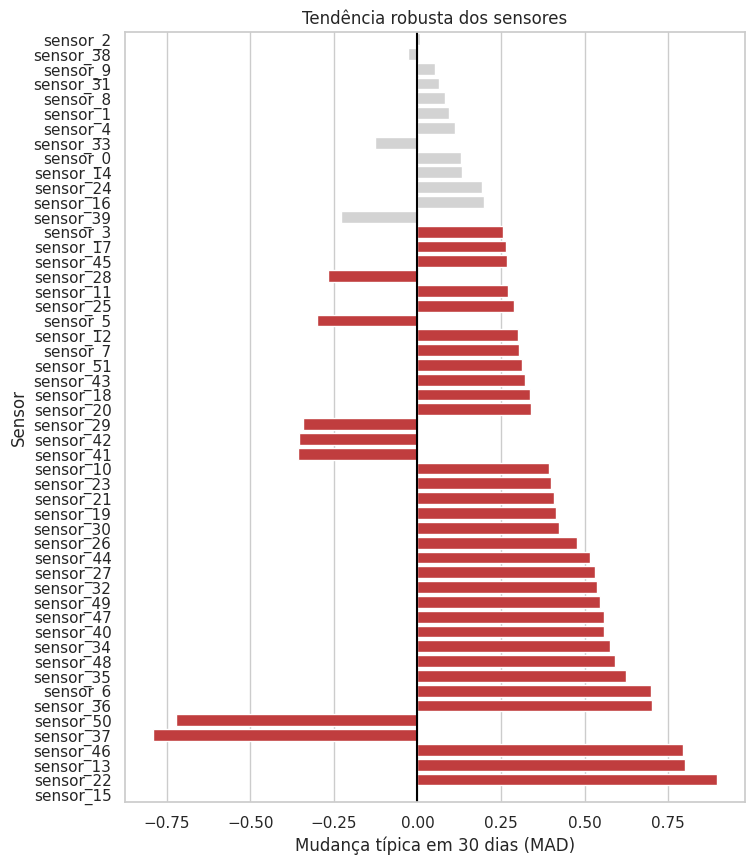

In [13]:
tendencias = diario.apply(analisar_tendencia).T
tendencias["q_value"] = corrigir_bh(tendencias.p_value)
tendencias["relevante"] = (tendencias.q_value < ALPHA) & (tendencias.efeito_30d_mad.abs() >= .25)

display(tendencias.sort_values("efeito_30d_mad", key=np.abs, ascending=False).head(12).round(3))

plt.figure(figsize=(8, 10))
sns.barplot(data=tendencias.reset_index().sort_values("efeito_30d_mad", key=np.abs), y="index", x="efeito_30d_mad", hue="relevante", dodge=False, palette={True: "tab:red", False: "lightgrey"}, legend=False)
plt.axvline(0, color="black")
plt.xlabel("Mudança típica em 30 dias (MAD)")
plt.ylabel("Sensor")
plt.title("Tendência robusta dos sensores")
plt.show()

Pode-se perceber que vários sensores possuem uma tendência relevante e, portanto, uma feature relacionada a tendência também é interessante para trazer ainda mais informações sobre os dados para o modelo.

> Obs: Essa feature não foi adicionada por conta de tempo

## Analisando período de falhas

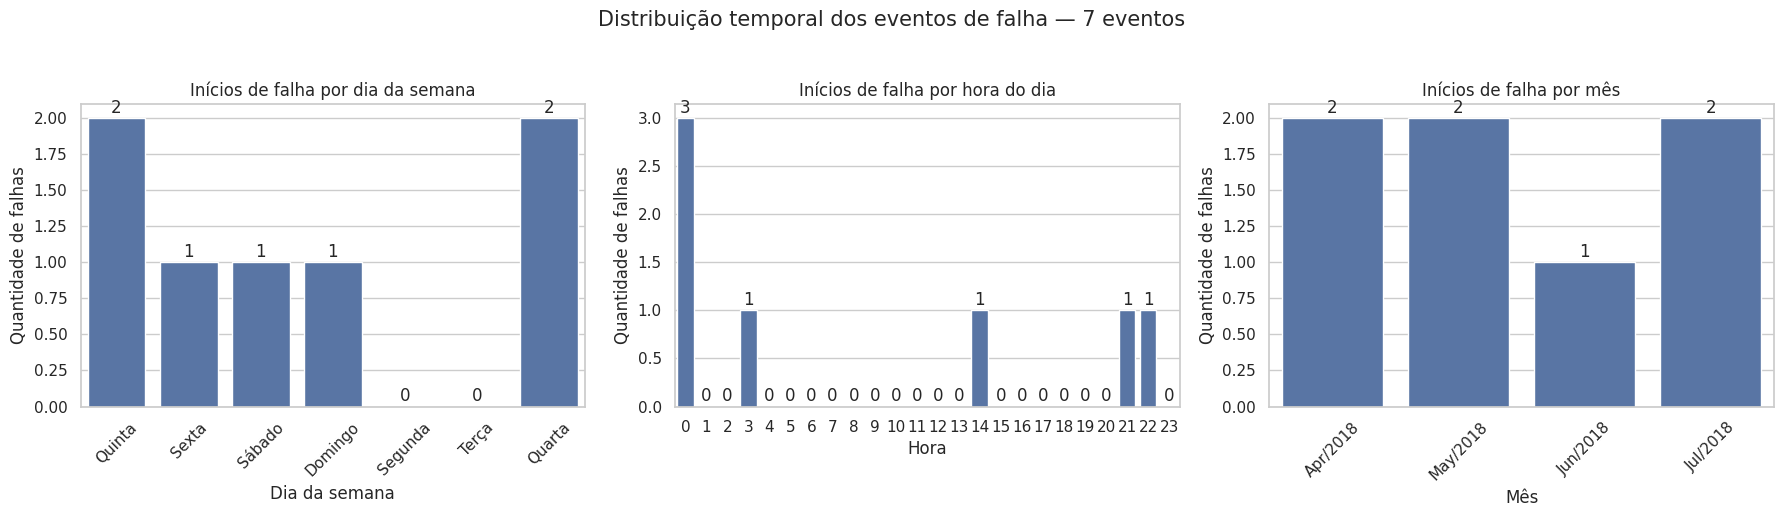

In [14]:
eventos_falha = plotar_distribuicao_temporal_falhas(eda_df)

As falhas parecem ter relação com o dia da semana e com as horas do dia. Nenhuma falha começou na segunda e terça, e 4 das 7 falhas começaram ou na quarta ou quinta. A maioria das falhas também começaram no período da noite/madrugada, apenas uma delas no período da tarde. Portanto a hora do dia também é uma boa feature adicional para o nosso modelo.

Em contrapartida, os meses não parecem influenciar tanto, uma vez que as falhas estão bem distribuidas.

,p_hora,forca_hora,p_dia_semana,forca_dia_semana,q_hora,q_dia_semana,hora_relevante,dia_relevante
sensor_37,0.0,2.991,0.034,0.318,0.0,0.048,True,False
sensor_42,0.0,1.568,0.005,0.361,0.0,0.010,True,False
sensor_47,0.0,1.412,0.311,0.135,0.0,0.330,True,False
sensor_41,0.0,1.398,0.034,0.215,0.0,0.048,True,False
sensor_39,0.0,1.258,0.014,0.289,0.0,0.024,True,False
sensor_38,0.0,1.160,0.367,0.198,0.0,0.382,True,False
sensor_43,0.0,1.130,0.728,0.147,0.0,0.728,True,False
sensor_46,0.0,1.094,0.009,0.460,0.0,0.016,True,False
sensor_45,0.0,1.079,0.003,0.349,0.0,0.007,True,False
sensor_44,0.0,1.060,0.001,0.370,0.0,0.002,True,False


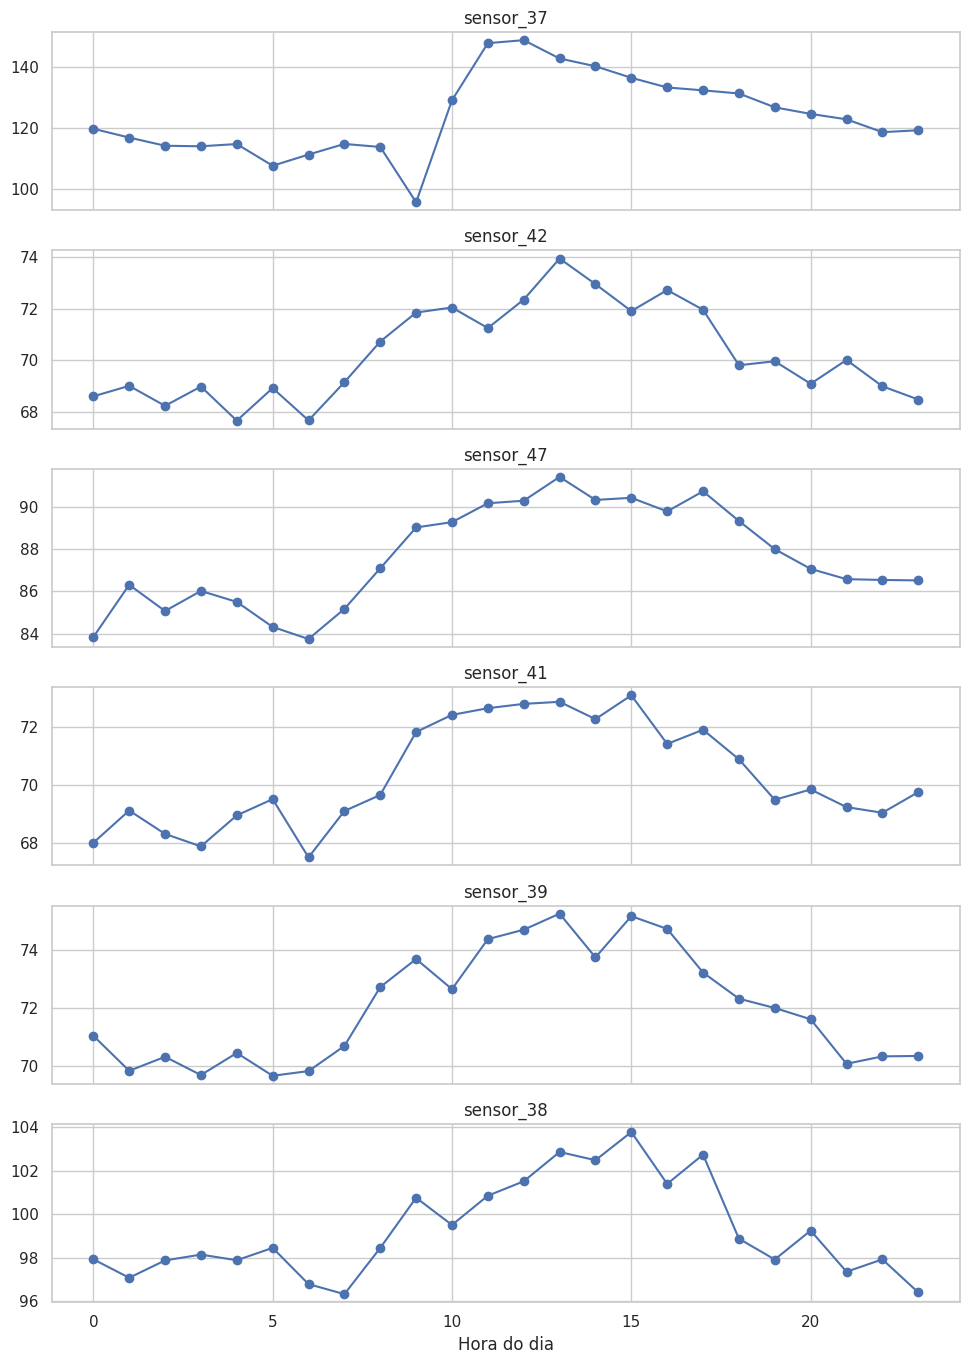

In [15]:
sazonalidade = horario.loc[:, horario.nunique().gt(1)].apply(analisar_sazonalidade).T.reindex(sensores)
sazonalidade["q_hora"] = corrigir_bh(sazonalidade.p_hora)
sazonalidade["q_dia_semana"] = corrigir_bh(sazonalidade.p_dia_semana)
sazonalidade["hora_relevante"] = (sazonalidade.q_hora < ALPHA) & (sazonalidade.forca_hora >= .5)
sazonalidade["dia_relevante"] = (sazonalidade.q_dia_semana < ALPHA) & (sazonalidade.forca_dia_semana >= .5)

display(sazonalidade.sort_values("forca_hora", ascending=False).head(12).round(3))

selecionados = sazonalidade.query("hora_relevante").nlargest(6, "forca_hora").index
fig, axes = plt.subplots(len(selecionados), 1, figsize=(10, 2.3 * len(selecionados)), sharex=True)

for ax, sensor in zip(np.atleast_1d(axes), selecionados):
    horario[sensor].groupby(horario.index.hour).median().plot(ax=ax, marker="o")
    ax.set_title(sensor)
    
plt.xlabel("Hora do dia")
plt.tight_layout()
plt.show()

Podemos observar que há alguma sazonalidade diária evidente para alguns dos sensores. Parece ter uma sazonalidade relacionada ao expediente de trabalho talvez, uma vez que no período da manhã pra tarde os sensores tendem a subir e depois descer.